# Telco Customer Churn Analysis
### Retention Analysis · Churn Patterns · Customer Lifetime Trends · Business Recommendations



## Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#2e3250',
    'axes.labelcolor'  : '#c8cfe8',
    'axes.titlecolor'  : '#ffffff',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'xtick.color'      : '#8892b0',
    'ytick.color'      : '#8892b0',
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'grid.color'       : '#2e3250',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'text.color'       : '#c8cfe8',
    'font.family'      : 'DejaVu Sans',
    'figure.dpi'       : 130,
})

CHURN_RED   = '#ff4d6d'
RETAIN_TEAL = '#00d4aa'
ACCENT_BLUE = '#4d8cff'
AMBER       = '#ffb347'
PURPLE      = '#b57bee'
PALETTE     = [RETAIN_TEAL, CHURN_RED, ACCENT_BLUE, AMBER, PURPLE,
               '#ff6b9d', '#56cfaa', '#ffd166', '#06d6a0', '#ef476f']


## Load & Inspect Data

In [2]:
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape         : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Memory usage  : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
df_raw.head()

Shape         : 7,043 rows × 21 columns
Memory usage  : 6984.7 KB



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(' Column Data Types ')
print(df_raw.dtypes)
print()
print(' Missing / Blank Values')
blanks = (df_raw == ' ').sum()
nulls  = df_raw.isnull().sum()
issues = pd.DataFrame({'nulls': nulls, 'blanks': blanks})
print(issues[issues.sum(axis=1) > 0])

 Column Data Types 
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

 Missing / Blank Values
              nulls  blanks
TotalCharges      0      11


### data cleaning

In [4]:
df = df_raw.copy()


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
blank_mask = df['TotalCharges'].isna()
df.loc[blank_mask, 'TotalCharges'] = df.loc[blank_mask, 'MonthlyCharges']
print(f'Fixed {blank_mask.sum()} blank TotalCharges rows (new customers with tenure=0)')


df['Churn_Flag'] = (df['Churn'] == 'Yes').astype(int)
df['IsSenior']   = df['SeniorCitizen']


df['TenureBand'] = pd.cut(
    df['tenure'],
    bins  = [0, 6, 12, 24, 36, 48, 72],
    labels= ['0–6 mo', '7–12 mo', '13–24 mo', '25–36 mo', '37–48 mo', '49–72 mo'],
    right = True
)


df['ChargeBand'] = pd.cut(
    df['MonthlyCharges'],
    bins  = [0, 30, 50, 70, 90, 120],
    labels= ['<$30', '$30–50', '$50–70', '$70–90', '$90+']
)

print(f'\nCleaned dataset shape : {df.shape}')
print(f'Remaining nulls       : {df.isnull().sum().sum()}')
df.head(3)

Fixed 11 blank TotalCharges rows (new customers with tenure=0)

Cleaned dataset shape : (7043, 25)
Remaining nulls       : 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,IsSenior,TenureBand,ChargeBand
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0,0–6 mo,<$30
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,0,0,25–36 mo,$50–70
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0,0–6 mo,$50–70


In [5]:
print('─── Descriptive Statistics (Numerical Columns) ──────')
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

─── Descriptive Statistics (Numerical Columns) ──────


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.80
std,24.56,30.09,2266.73
min,0.00,18.25,18.80
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


## Overall Churn & Revenue Overview

In [6]:
total        = len(df)
churned      = df['Churn_Flag'].sum()
retained     = total - churned
churn_rate   = churned / total
monthly_rev  = df['MonthlyCharges'].sum()
lost_rev     = df[df['Churn_Flag']==1]['MonthlyCharges'].sum()
clv_retained = (df[df['Churn_Flag']==0]['MonthlyCharges'].mean() *
                df[df['Churn_Flag']==0]['tenure'].mean())
monthly_churn_rate = 1 - (1 - churn_rate) ** (1/12)

print(f'Total Customers : {total:>7,}')
print(f'Churned Customers : {churned:>7,}  ({churn_rate*100:.1f}%)')
print(f'Retained Customers: {retained:>7,}  ({(1-churn_rate)*100:.1f}%)')
print(f'Monthly Revenue : ${monthly_rev:>10,.2f}')
print(f'Revenue at Risk/Mo : ${lost_rev:>10,.2f}  ({lost_rev/monthly_rev*100:.1f}%)')
print(f'Avg CLV (Retained): ${clv_retained:>10,.2f}')
print(f' Monthly Churn Rate: {monthly_churn_rate*100:>7.2f}%')

Total Customers :   7,043
Churned Customers :   1,869  (26.5%)
Retained Customers:   5,174  (73.5%)
Monthly Revenue : $456,116.60
Revenue at Risk/Mo : $139,130.85  (30.5%)
Avg CLV (Retained): $  2,301.73
 Monthly Churn Rate:    2.54%


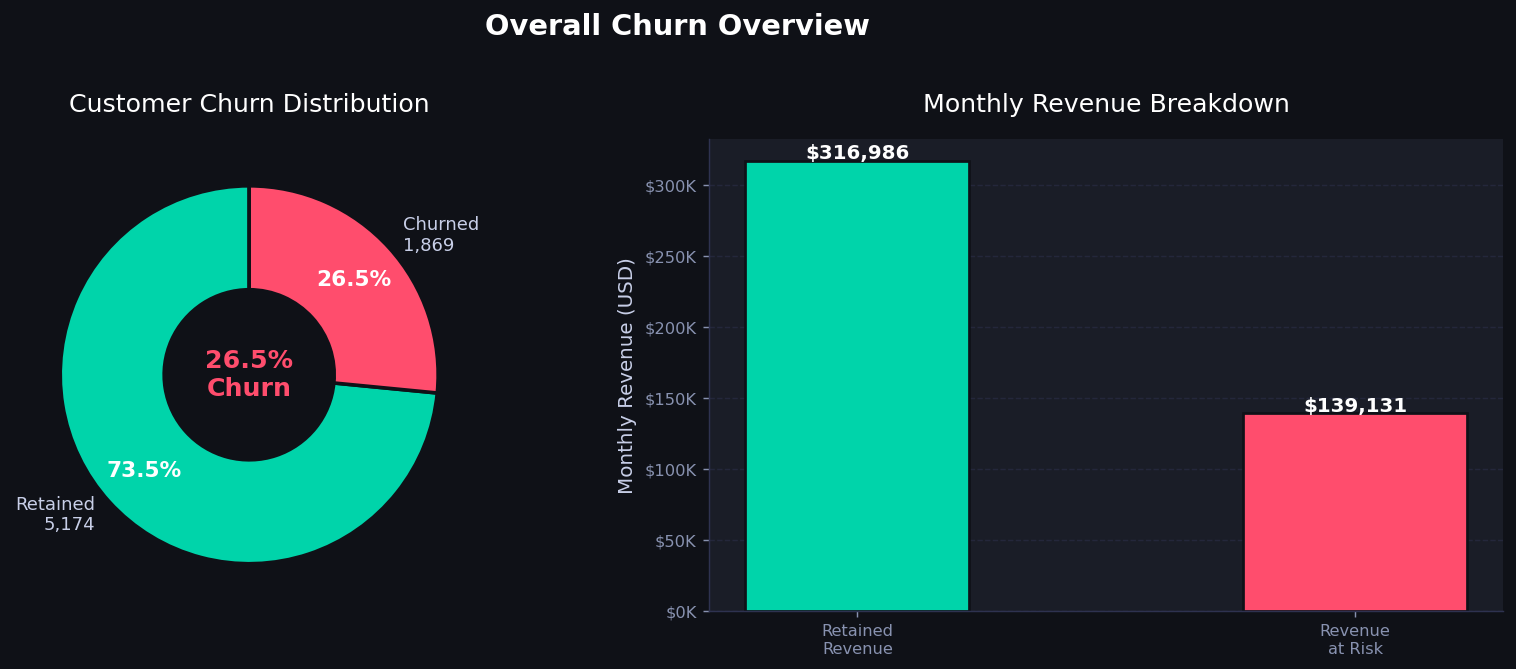

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Overall Churn Overview', fontsize=16, fontweight='bold', color='white', y=1.02)

ax1 = axes[0]
sizes  = [retained, churned]
labels = [f'Retained\n{retained:,}', f'Churned\n{churned:,}']
colors = [RETAIN_TEAL, CHURN_RED]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.75, wedgeprops=dict(width=0.55, edgecolor='#0f1117', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')
for t in texts:
    t.set_color('#c8cfe8')
    t.set_fontsize(10)
ax1.text(0, 0, f'{churn_rate*100:.1f}%\nChurn', ha='center', va='center',
         fontsize=14, fontweight='bold', color=CHURN_RED)
ax1.set_title('Customer Churn Distribution', pad=15)


ax2 = axes[1]
rev_data  = [monthly_rev - lost_rev, lost_rev]
rev_label = ['Retained\nRevenue', 'Revenue\nat Risk']
bars = ax2.bar(rev_label, rev_data, color=[RETAIN_TEAL, CHURN_RED],
               width=0.45, edgecolor='#0f1117', linewidth=1.5)
for bar, val in zip(bars, rev_data):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
             f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold', color='white')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.set_title('Monthly Revenue Breakdown', pad=15)
ax2.set_ylabel('Monthly Revenue (USD)')
ax2.yaxis.grid(True)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Churn by Key Segments

In [8]:
def churn_by(col):
    return (
        df.groupby(col)['Churn_Flag']
        .agg(['mean', 'sum', 'count'])
        .rename(columns={'mean':'churn_rate','sum':'churned','count':'total'})
        .sort_values('churn_rate', ascending=False)
        .assign(churn_rate=lambda x: (x['churn_rate']*100).round(1))
    )

print('Churn by Contract')
print(churn_by('Contract').to_string())
print('\n Churn by Internet Service')
print(churn_by('InternetService').to_string())
print('\n Churn by Payment Method')
print(churn_by('PaymentMethod').to_string())

Churn by Contract
                churn_rate  churned  total
Contract                                  
Month-to-month        42.7     1655   3875
One year              11.3      166   1473
Two year               2.8       48   1695

 Churn by Internet Service
                 churn_rate  churned  total
InternetService                            
Fiber optic            41.9     1297   3096
DSL                    19.0      459   2421
No                      7.4      113   1526

 Churn by Payment Method
                           churn_rate  churned  total
PaymentMethod                                        
Electronic check                 45.3     1071   2365
Mailed check                     19.1      308   1612
Bank transfer (automatic)        16.7      258   1544
Credit card (automatic)          15.2      232   1522


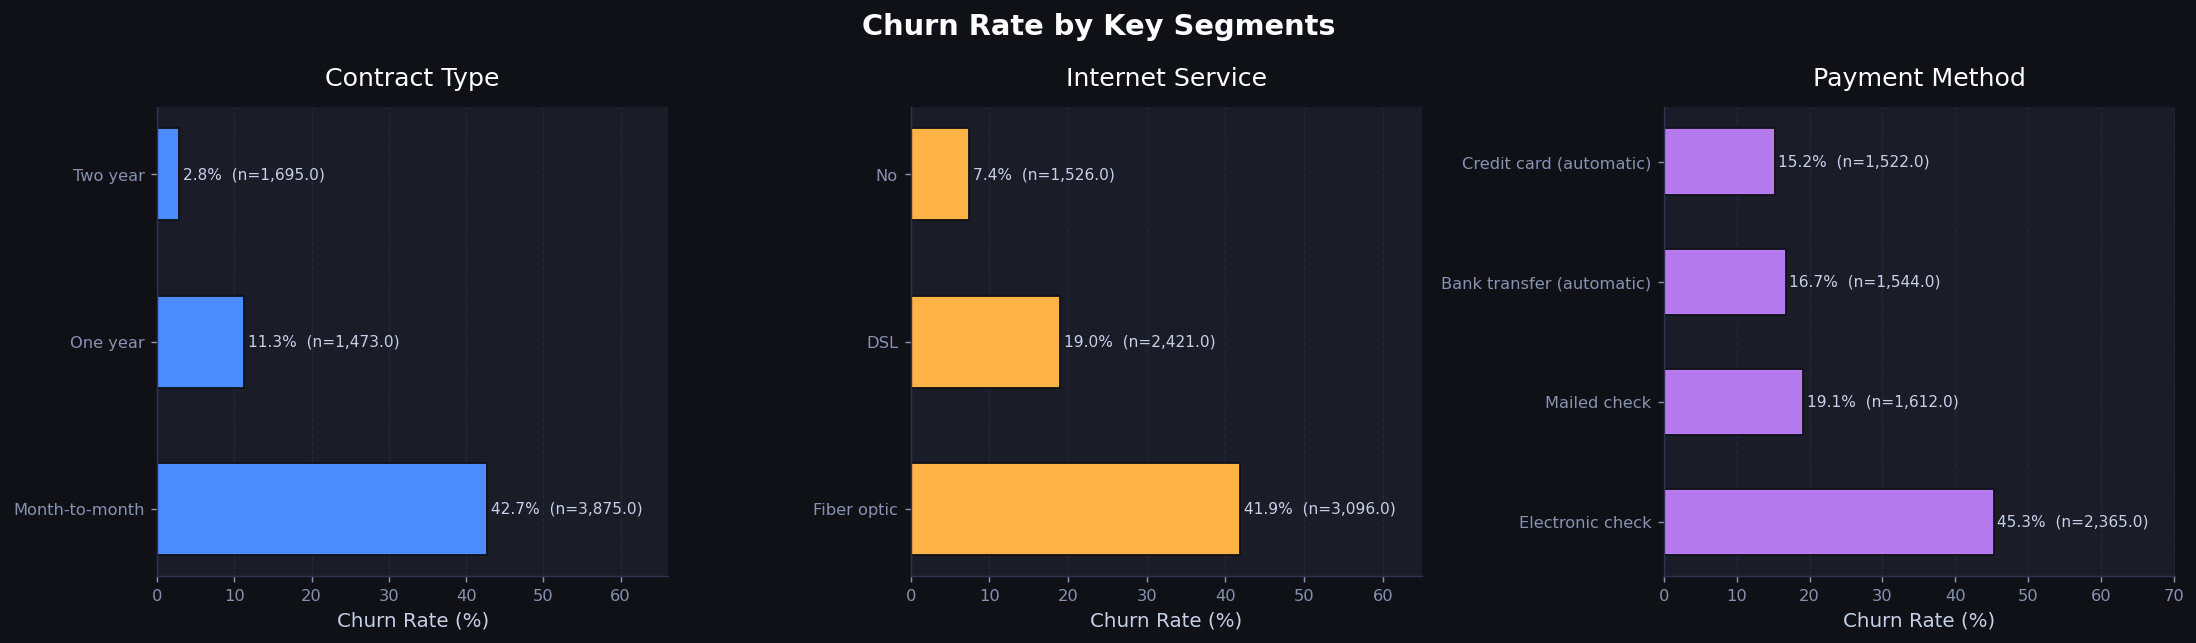

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Churn Rate by Key Segments', fontsize=16, fontweight='bold', color='white')

segments = [
    ('Contract',       'Contract Type',    ACCENT_BLUE),
    ('InternetService','Internet Service', AMBER),
    ('PaymentMethod',  'Payment Method',   PURPLE),
]

for ax, (col, title, color) in zip(axes, segments):
    data = churn_by(col)
    bars = ax.barh(data.index, data['churn_rate'], color=color,
                   edgecolor='#0f1117', linewidth=1, height=0.55)
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{row['churn_rate']:.1f}%  (n={row['total']:,})",
                va='center', fontsize=8.5, color='#c8cfe8')
    ax.set_xlim(0, data['churn_rate'].max() * 1.55)
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(title, pad=12)
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##  Churn by Tenure & Customer Lifetime

In [10]:
tenure_stats = (
    df.groupby('TenureBand', observed=True)
    .agg(
        customers  = ('Churn_Flag', 'count'),
        churned    = ('Churn_Flag', 'sum'),
        churn_rate = ('Churn_Flag', 'mean'),
        avg_monthly= ('MonthlyCharges', 'mean')
    )
    .assign(churn_rate=lambda x: (x['churn_rate']*100).round(1))
    .assign(avg_monthly=lambda x: x['avg_monthly'].round(2))
)
print(tenure_stats.to_string())

            customers  churned  churn_rate  avg_monthly
TenureBand                                             
0–6 mo           1470      784        53.3        54.84
7–12 mo           705      253        35.9        58.95
13–24 mo         1024      294        28.7        61.36
25–36 mo          832      180        21.6        65.58
37–48 mo          762      145        19.0        66.32
49–72 mo         2239      213         9.5        73.95


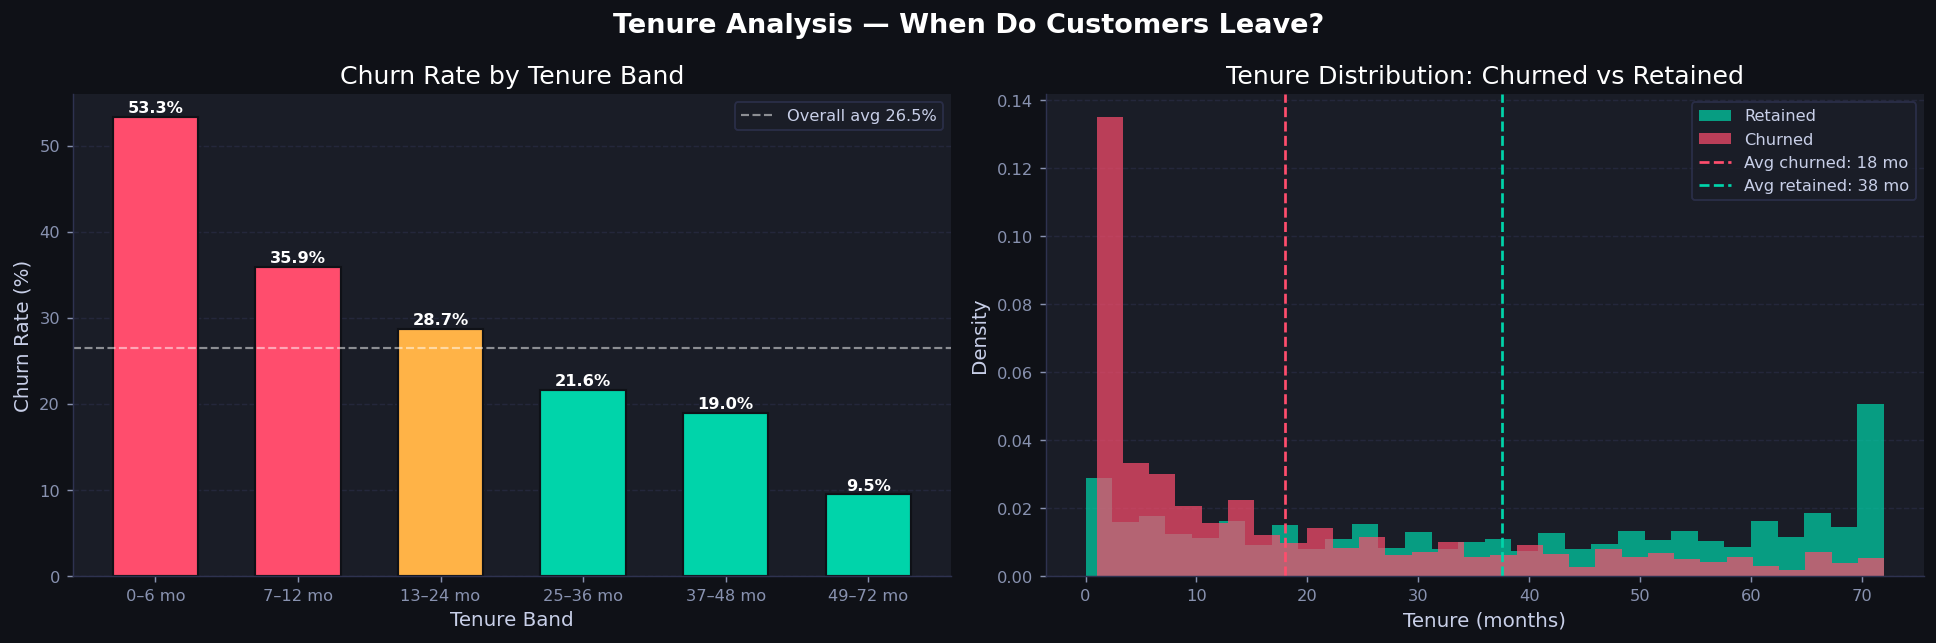

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Tenure Analysis — When Do Customers Leave?', fontsize=15, fontweight='bold', color='white')

ax1 = axes[0]
colors_bar = [CHURN_RED if r > 35 else AMBER if r > 28 else RETAIN_TEAL
              for r in tenure_stats['churn_rate']]
bars = ax1.bar(tenure_stats.index.astype(str), tenure_stats['churn_rate'],
               color=colors_bar, edgecolor='#0f1117', linewidth=1.2, width=0.6)
for bar, val in zip(bars, tenure_stats['churn_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=9, fontweight='bold', color='white')
ax1.axhline(churn_rate*100, color='#ffffff', linestyle='--', linewidth=1.2, alpha=0.5,
            label=f'Overall avg {churn_rate*100:.1f}%')
ax1.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#2e3250')
ax1.set_xlabel('Tenure Band')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('Churn Rate by Tenure Band')
ax1.yaxis.grid(True)
ax1.set_axisbelow(True)

ax2 = axes[1]
churned_tenure  = df[df['Churn_Flag']==1]['tenure']
retained_tenure = df[df['Churn_Flag']==0]['tenure']
ax2.hist(retained_tenure, bins=30, alpha=0.7, color=RETAIN_TEAL, label='Retained', density=True)
ax2.hist(churned_tenure,  bins=30, alpha=0.7, color=CHURN_RED,   label='Churned',  density=True)
ax2.axvline(churned_tenure.mean(),  color=CHURN_RED,   linestyle='--', linewidth=1.5,
            label=f'Avg churned: {churned_tenure.mean():.0f} mo')
ax2.axvline(retained_tenure.mean(), color=RETAIN_TEAL, linestyle='--', linewidth=1.5,
            label=f'Avg retained: {retained_tenure.mean():.0f} mo')
ax2.set_xlabel('Tenure (months)')
ax2.set_ylabel('Density')
ax2.set_title('Tenure Distribution: Churned vs Retained')
ax2.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#2e3250')
ax2.yaxis.grid(True)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Churn by Monthly Charges

In [12]:
charge_stats = (
    df.groupby('ChargeBand', observed=True)['Churn_Flag']
    .agg(['mean','count','sum'])
    .rename(columns={'mean':'churn_rate','count':'customers','sum':'churned'})
    .assign(churn_rate=lambda x: (x['churn_rate']*100).round(1))
)
print(charge_stats.to_string())

            churn_rate  customers  churned
ChargeBand                                
<$30               9.8       1653      162
$30–50            30.8        646      199
$50–70            20.8       1161      241
$70–90            37.8       1844      697
$90+              32.8       1739      570


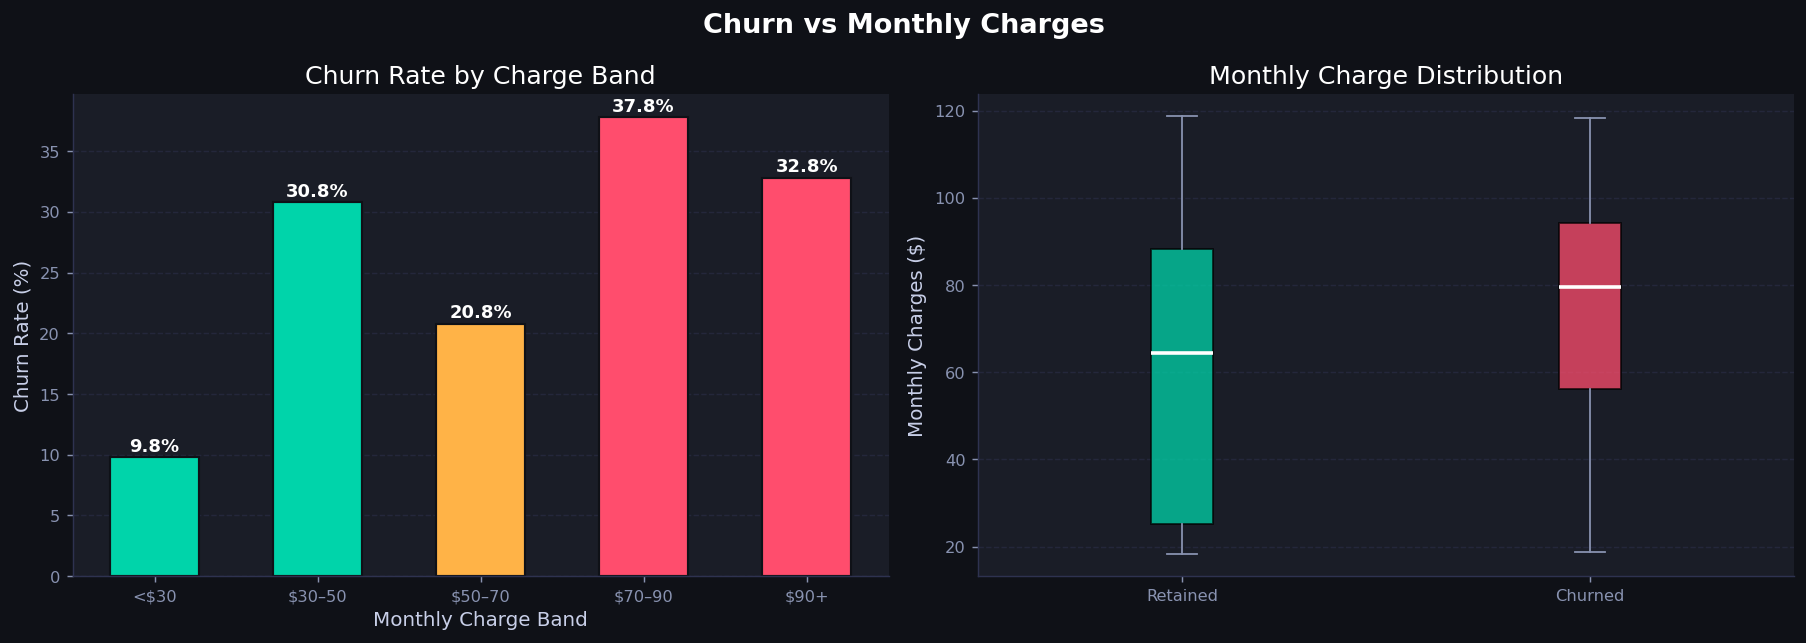

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn vs Monthly Charges', fontsize=15, fontweight='bold', color='white')

ax1 = axes[0]
colors_c = [RETAIN_TEAL, RETAIN_TEAL, AMBER, CHURN_RED, CHURN_RED]
bars = ax1.bar(charge_stats.index.astype(str), charge_stats['churn_rate'],
               color=colors_c, edgecolor='#0f1117', linewidth=1.2, width=0.55)
for bar, val in zip(bars, charge_stats['churn_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', fontsize=10, fontweight='bold', color='white')
ax1.set_xlabel('Monthly Charge Band')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_title('Churn Rate by Charge Band')
ax1.yaxis.grid(True)
ax1.set_axisbelow(True)

ax2 = axes[1]
data_box   = [df[df['Churn_Flag']==0]['MonthlyCharges'],
              df[df['Churn_Flag']==1]['MonthlyCharges']]
bp = ax2.boxplot(data_box, patch_artist=True, notch=False,
                 medianprops=dict(color='white', linewidth=2),
                 whiskerprops=dict(color='#8892b0'),
                 capprops=dict(color='#8892b0'),
                 flierprops=dict(marker='o', color='#8892b0', alpha=0.3, markersize=3))
for patch, color in zip(bp['boxes'], [RETAIN_TEAL, CHURN_RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticklabels(['Retained', 'Churned'])
ax2.set_ylabel('Monthly Charges ($)')
ax2.set_title('Monthly Charge Distribution')
ax2.yaxis.grid(True)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

##  Demographic Segmentation

In [14]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
for col in demo_cols:
    print(f'Churn by {col}')
    t = df.groupby(col)['Churn_Flag'].agg(['mean','count'])
    t['mean'] = (t['mean']*100).round(1)
    print(t.rename(columns={'mean':'churn_%','count':'customers'}).to_string())
    print()

Churn by gender
        churn_%  customers
gender                    
Female     26.9       3488
Male       26.2       3555

Churn by SeniorCitizen
               churn_%  customers
SeniorCitizen                    
0                 23.6       5901
1                 41.7       1142

Churn by Partner
         churn_%  customers
Partner                    
No          33.0       3641
Yes         19.7       3402

Churn by Dependents
            churn_%  customers
Dependents                    
No             31.3       4933
Yes            15.5       2110



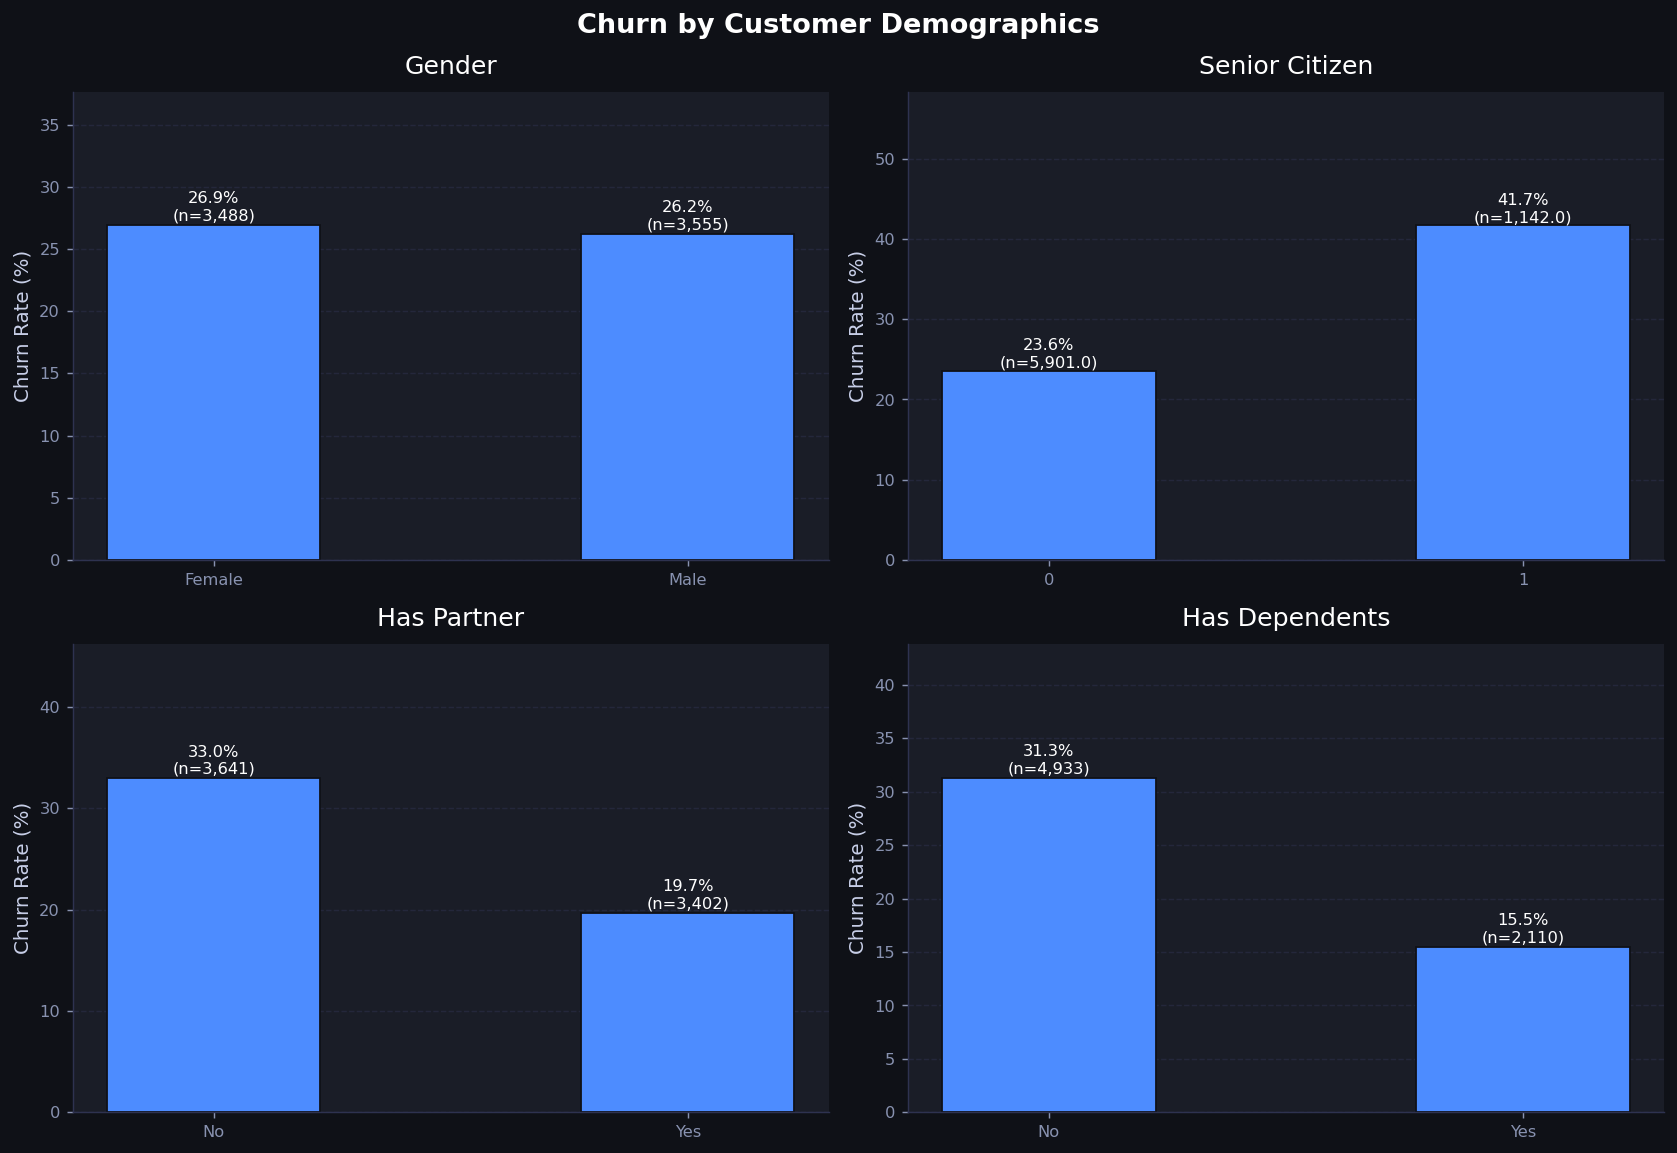

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Churn by Customer Demographics', fontsize=15, fontweight='bold', color='white')
axes = axes.flatten()

demo_items = [
    ('gender',        'Gender',          {0: RETAIN_TEAL, 1: CHURN_RED}),
    ('SeniorCitizen', 'Senior Citizen',  {0: RETAIN_TEAL, 1: CHURN_RED}),
    ('Partner',       'Has Partner',     {'No': CHURN_RED, 'Yes': RETAIN_TEAL}),
    ('Dependents',    'Has Dependents',  {'No': CHURN_RED, 'Yes': RETAIN_TEAL}),
]

for ax, (col, title, cmap) in zip(axes, demo_items):
    t = df.groupby(col)['Churn_Flag'].agg(['mean','count']).reset_index()
    t['churn_pct'] = (t['mean']*100).round(1)
    bar_colors = [ACCENT_BLUE] * len(t)
    bars = ax.bar(t[col].astype(str), t['churn_pct'],
                  color=ACCENT_BLUE, edgecolor='#0f1117', linewidth=1, width=0.45)
    for bar, (_, row) in zip(bars, t.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f"{row['churn_pct']}%\n(n={row['count']:,})",
                ha='center', fontsize=9, color='white')
    ax.set_title(title, pad=10)
    ax.set_ylabel('Churn Rate (%)')
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.set_ylim(0, t['churn_pct'].max() * 1.4)

plt.tight_layout()
plt.show()

## Add-on Services & Churn Protection

In [16]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = {}
for col in service_cols:
    yes_churn = df[df[col]=='Yes']['Churn_Flag'].mean() * 100
    no_churn  = df[df[col]=='No' ]['Churn_Flag'].mean() * 100
    service_churn[col] = {'With Service': round(yes_churn, 1),
                          'Without Service': round(no_churn, 1),
                          'Protection': round(no_churn - yes_churn, 1)}

svc_df = pd.DataFrame(service_churn).T.sort_values('Protection', ascending=False)
print(svc_df.to_string())

                  With Service  Without Service  Protection
OnlineSecurity            14.6             41.8        27.2
TechSupport               15.2             41.6        26.5
OnlineBackup              21.5             39.9        18.4
DeviceProtection          22.5             39.1        16.6
StreamingMovies           29.9             33.7         3.7
StreamingTV               30.1             33.5         3.5


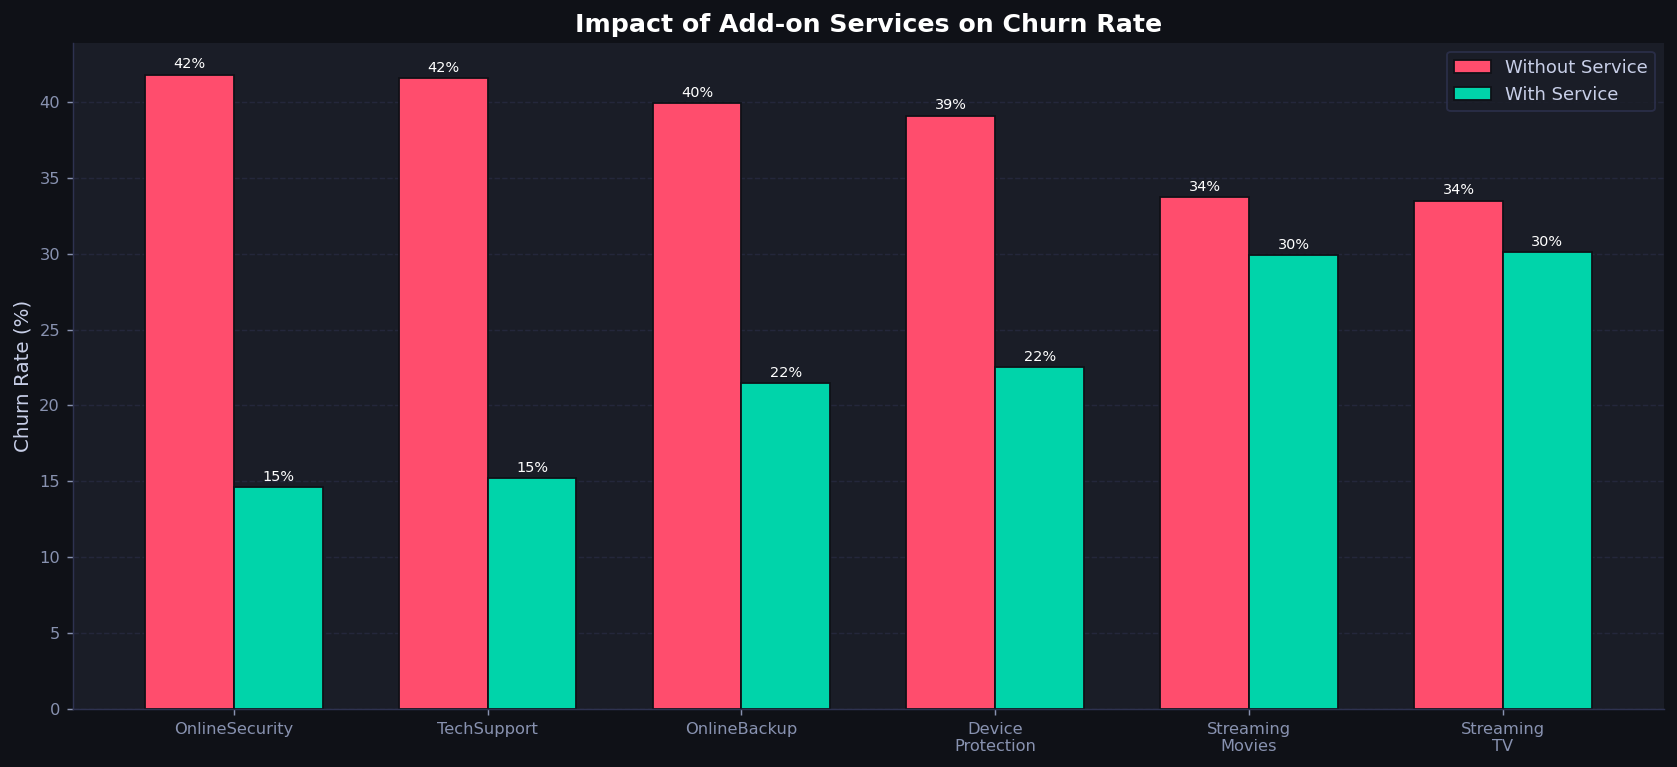

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor('#1a1d27')

x     = np.arange(len(svc_df))
width = 0.35
labels = [c.replace('Streaming', 'Streaming\n').replace('Device', 'Device\n') for c in svc_df.index]

b1 = ax.bar(x - width/2, svc_df['Without Service'], width, label='Without Service',
            color=CHURN_RED, edgecolor='#0f1117', linewidth=1)
b2 = ax.bar(x + width/2, svc_df['With Service'],    width, label='With Service',
            color=RETAIN_TEAL, edgecolor='#0f1117', linewidth=1)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.0f}%', ha='center', fontsize=8, color='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Impact of Add-on Services on Churn Rate', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, facecolor='#1a1d27', edgecolor='#2e3250')
ax.yaxis.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Churn Risk Factor Analysis

In [18]:

drivers = {
    'Month-to-month contract'      : df[df['Contract']=='Month-to-month']['Churn_Flag'].mean(),
    'Fiber optic + no security'    : df[(df['InternetService']=='Fiber optic') &
                                        (df['OnlineSecurity']=='No')]['Churn_Flag'].mean(),
    'Monthly charges > $80'        : df[df['MonthlyCharges']>80]['Churn_Flag'].mean(),
    'Tenure < 12 months'           : df[df['tenure']<12]['Churn_Flag'].mean(),
    'Electronic check payment'     : df[df['PaymentMethod']=='Electronic check']['Churn_Flag'].mean(),
    'No tech support'              : df[(df['TechSupport']=='No') &
                                        (df['InternetService']!='No')]['Churn_Flag'].mean(),
    'No online security'           : df[(df['OnlineSecurity']=='No') &
                                        (df['InternetService']!='No')]['Churn_Flag'].mean(),
    'Senior citizen'               : df[df['SeniorCitizen']==1]['Churn_Flag'].mean(),
    'No partner + no dependents'   : df[(df['Partner']=='No') &
                                        (df['Dependents']=='No')]['Churn_Flag'].mean(),
    'Paperless billing'            : df[df['PaperlessBilling']=='Yes']['Churn_Flag'].mean(),
}
drivers_pct = {k: round(v*100, 1) for k, v in drivers.items()}
drivers_df  = pd.DataFrame.from_dict(drivers_pct, orient='index', columns=['churn_rate'])
drivers_df  = drivers_df.sort_values('churn_rate', ascending=True)
print(drivers_df.to_string())

                            churn_rate
Paperless billing                 33.6
Monthly charges > $80             34.0
No partner + no dependents        34.2
No tech support                   41.6
Senior citizen                    41.7
No online security                41.8
Month-to-month contract           42.7
Electronic check payment          45.3
Tenure < 12 months                48.3
Fiber optic + no security         49.4


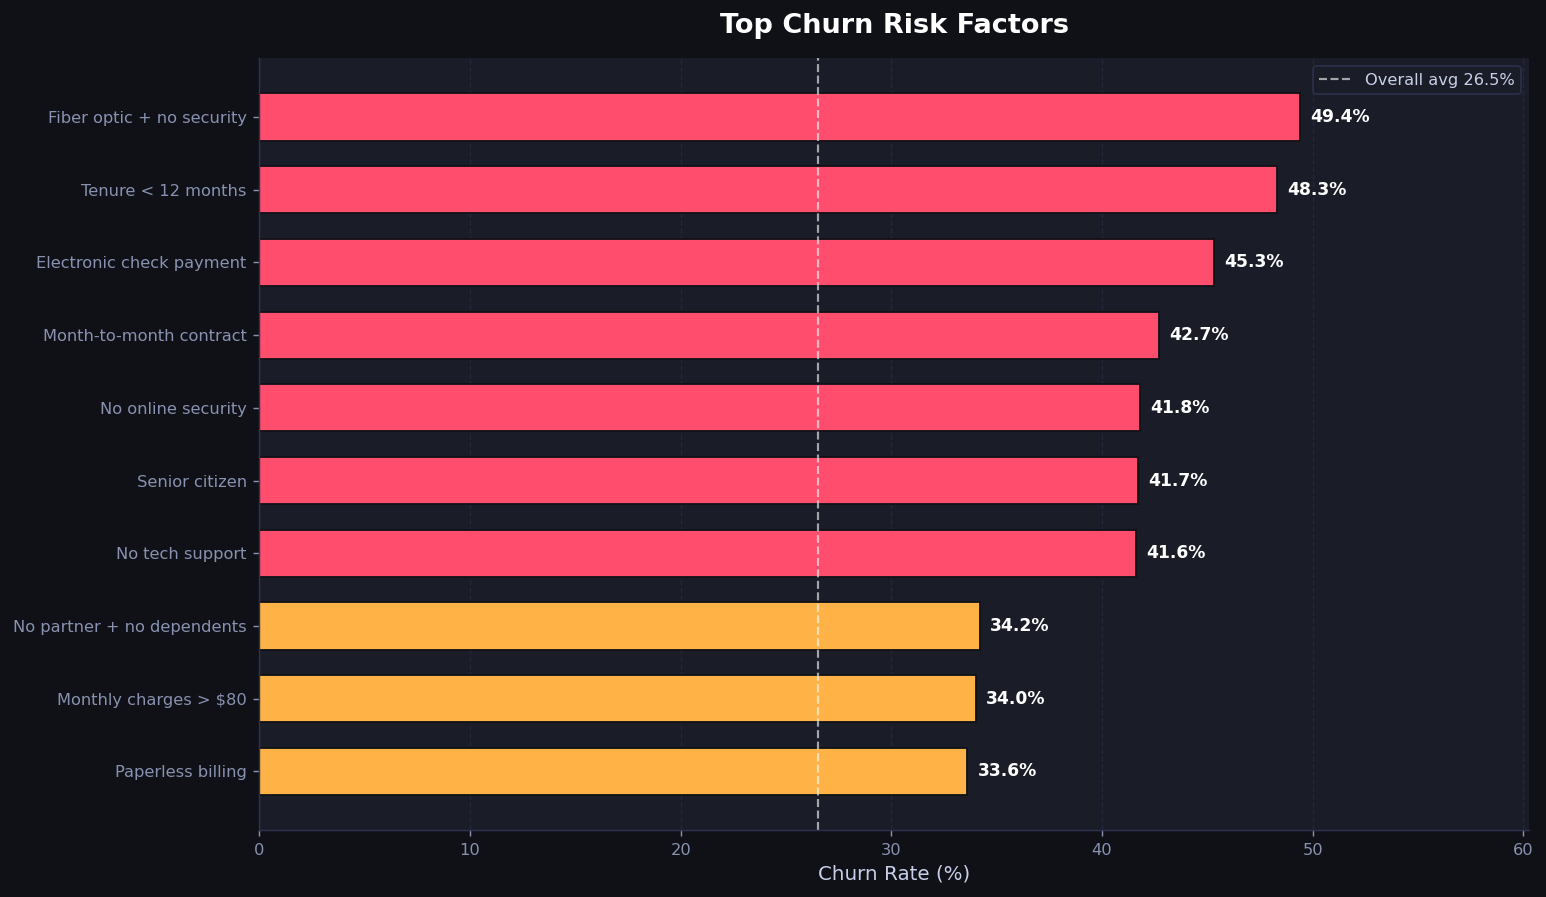

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

bar_colors = [CHURN_RED if v > 40 else AMBER if v > 30 else RETAIN_TEAL
              for v in drivers_df['churn_rate']]
bars = ax.barh(drivers_df.index, drivers_df['churn_rate'],
               color=bar_colors, edgecolor='#0f1117', linewidth=1, height=0.65)

ax.axvline(churn_rate*100, color='white', linestyle='--', linewidth=1.2, alpha=0.6,
           label=f'Overall avg {churn_rate*100:.1f}%')

for bar, val in zip(bars, drivers_df['churn_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9.5, fontweight='bold', color='white')

ax.set_xlim(0, drivers_df['churn_rate'].max() * 1.22)
ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_title('Top Churn Risk Factors', fontsize=15, fontweight='bold', pad=14)
ax.legend(fontsize=9, facecolor='#1a1d27', edgecolor='#2e3250')
ax.xaxis.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##  Cohort Analysis (by Contract × Tenure)

In [20]:
cohort = (
    df.groupby(['Contract', 'TenureBand'], observed=True)
    .agg(
        customers  = ('Churn_Flag', 'count'),
        churn_rate = ('Churn_Flag', 'mean'),
        avg_monthly= ('MonthlyCharges', 'mean')
    )
    .reset_index()
    .assign(churn_rate =lambda x: (x['churn_rate']*100).round(1),
            avg_monthly=lambda x: x['avg_monthly'].round(1))
)

cohort_pivot = cohort.pivot(index='Contract', columns='TenureBand', values='churn_rate')
print('Cohort Churn Rate (%) — Contract × Tenure Band')
print(cohort_pivot.to_string())

Cohort Churn Rate (%) — Contract × Tenure Band
TenureBand      0–6 mo  7–12 mo  13–24 mo  25–36 mo  37–48 mo  49–72 mo
Contract                                                               
Month-to-month    55.2     42.0      37.7      32.5      33.5      26.0
One year          10.5     10.6       8.1       8.0      13.1      12.9
Two year           0.0      0.0       0.0       2.1       2.2       3.3


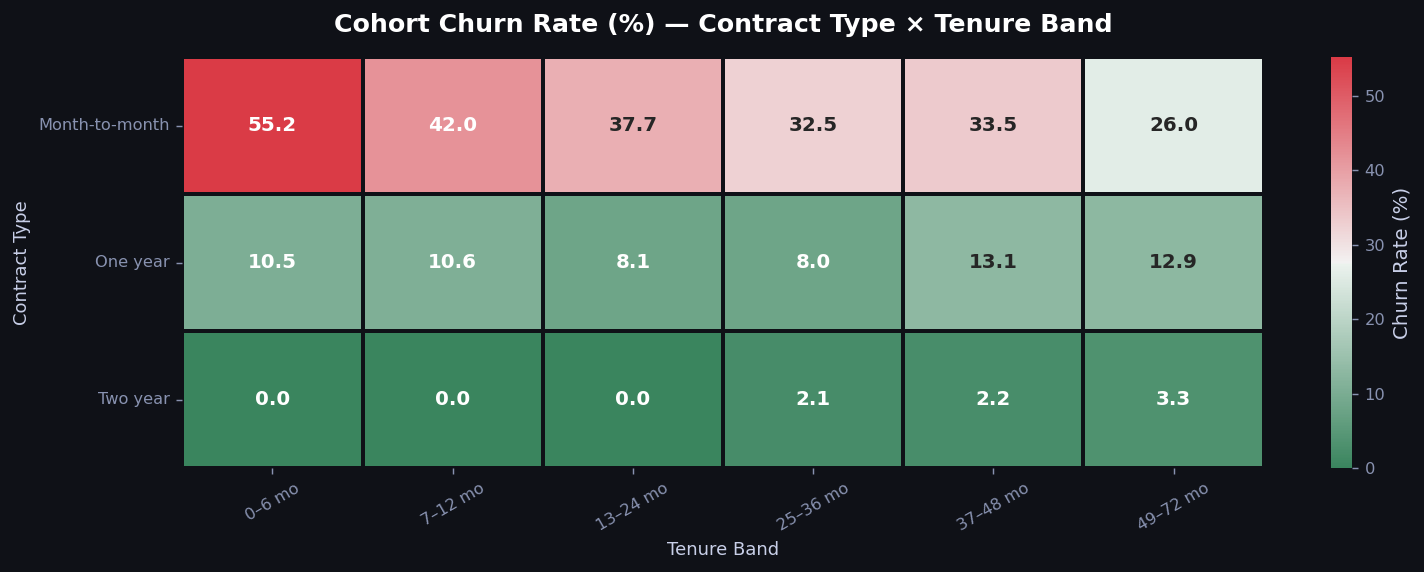

In [21]:
fig, ax = plt.subplots(figsize=(12, 4.5))

sns.heatmap(
    cohort_pivot,
    annot=True, fmt='.1f', linewidths=2, linecolor='#0f1117',
    cmap=sns.diverging_palette(145, 10, as_cmap=True),
    ax=ax, annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'label': 'Churn Rate (%)'}
)
ax.set_title('Cohort Churn Rate (%) — Contract Type × Tenure Band',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Tenure Band', fontsize=10)
ax.set_ylabel('Contract Type', fontsize=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## Customer Lifetime Value (CLV)

In [22]:
clv_by_contract = (
    df.groupby('Contract')
    .apply(lambda x: pd.Series({
        'avg_tenure_mo'  : round(x['tenure'].mean(), 1),
        'avg_monthly_$'  : round(x['MonthlyCharges'].mean(), 2),
        'estimated_CLV'  : round(x['MonthlyCharges'].mean() * x['tenure'].mean(), 2),
        'churn_rate_%'   : round(x['Churn_Flag'].mean() * 100, 1),
        'customers'      : len(x)
    }))
    .reset_index()
)
print('Customer Lifetime Value by Contract Type')
print(clv_by_contract.to_string(index=False))

Customer Lifetime Value by Contract Type
      Contract  avg_tenure_mo  avg_monthly_$  estimated_CLV  churn_rate_%  customers
Month-to-month           18.0          66.40        1197.61          42.7     3875.0
      One year           42.0          65.05        2734.96          11.3     1473.0
      Two year           56.7          60.77        3447.82           2.8     1695.0


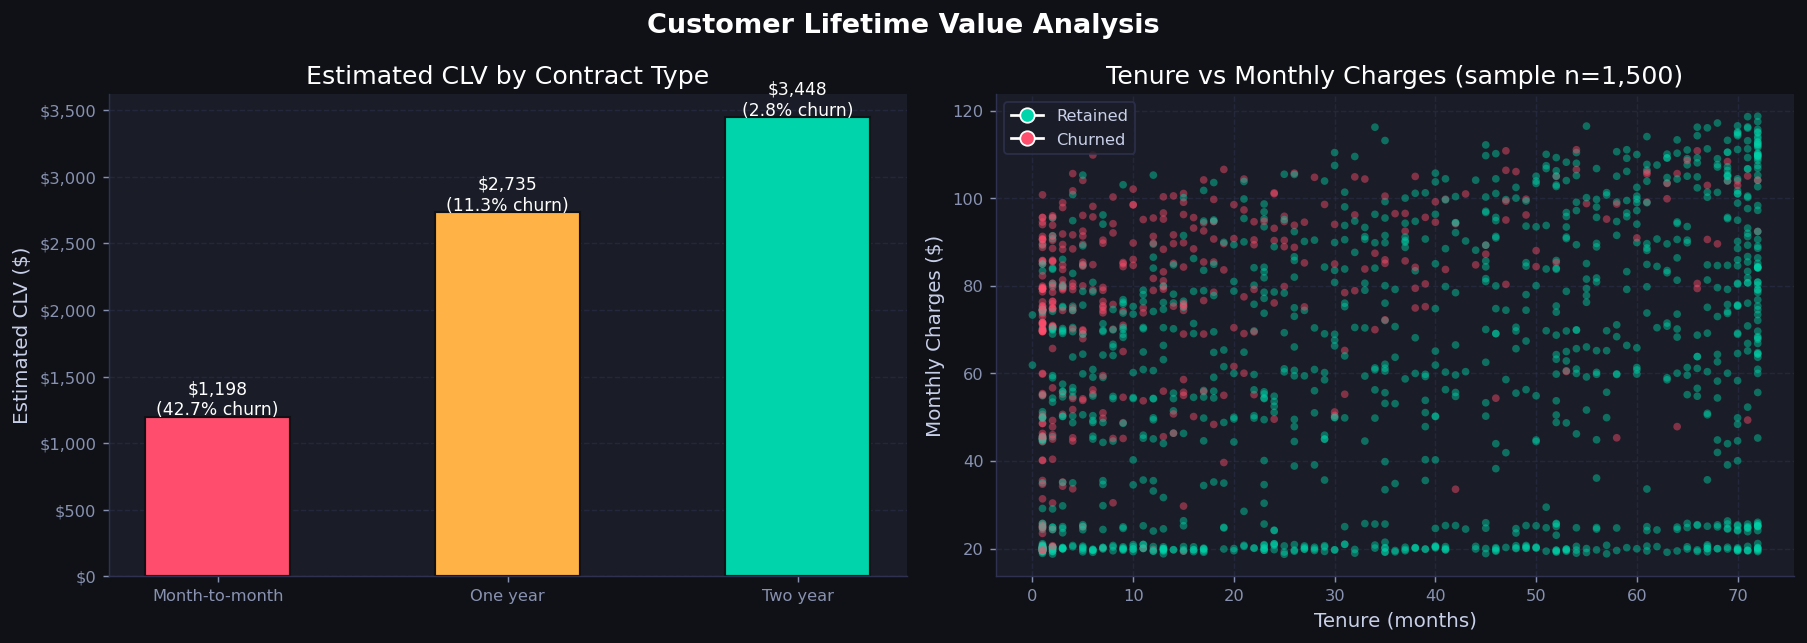

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=15, fontweight='bold', color='white')

ax1 = axes[0]
colors_clv = [CHURN_RED, AMBER, RETAIN_TEAL]
bars = ax1.bar(clv_by_contract['Contract'], clv_by_contract['estimated_CLV'],
               color=colors_clv, edgecolor='#0f1117', linewidth=1.2, width=0.5)
for bar, (_, row) in zip(bars, clv_by_contract.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f"${row['estimated_CLV']:,.0f}\n({row['churn_rate_%']}% churn)",
             ha='center', fontsize=9.5, color='white')
ax1.set_ylabel('Estimated CLV ($)')
ax1.set_title('Estimated CLV by Contract Type')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.yaxis.grid(True)
ax1.set_axisbelow(True)

ax2 = axes[1]
sample = df.sample(1500, random_state=42)
sc = ax2.scatter(
    sample['tenure'], sample['MonthlyCharges'],
    c=sample['Churn_Flag'].map({0: RETAIN_TEAL, 1: CHURN_RED}),
    alpha=0.45, s=18, linewidths=0
)
from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=RETAIN_TEAL, markersize=8, label='Retained'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=CHURN_RED,   markersize=8, label='Churned'),
]
ax2.legend(handles=legend_els, fontsize=9, facecolor='#1a1d27', edgecolor='#2e3250')
ax2.set_xlabel('Tenure (months)')
ax2.set_ylabel('Monthly Charges ($)')
ax2.set_title('Tenure vs Monthly Charges (sample n=1,500)')
ax2.yaxis.grid(True)
ax2.xaxis.grid(True)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Full Correlation Heatmap

In [24]:

df_enc = df.copy()
for col in df_enc.select_dtypes('object').columns:
    if col not in ['customerID', 'Churn']:
        df_enc[col] = pd.Categorical(df_enc[col]).codes
df_enc = df_enc.drop(columns=['customerID','Churn','TenureBand','ChargeBand'])

corr = df_enc.corr()[['Churn_Flag']].drop('Churn_Flag').sort_values('Churn_Flag')
print('Correlation with Churn (top positive & negative drivers):')
print(corr.to_string())

Correlation with Churn (top positive & negative drivers):
                  Churn_Flag
Contract           -0.396713
tenure             -0.352229
OnlineSecurity     -0.289309
TechSupport        -0.282492
TotalCharges       -0.198347
OnlineBackup       -0.195525
DeviceProtection   -0.178134
Dependents         -0.164221
Partner            -0.150448
InternetService    -0.047291
StreamingMovies    -0.038492
StreamingTV        -0.036581
gender             -0.008612
PhoneService        0.011942
MultipleLines       0.038037
PaymentMethod       0.107062
SeniorCitizen       0.150889
IsSenior            0.150889
PaperlessBilling    0.191825
MonthlyCharges      0.193356


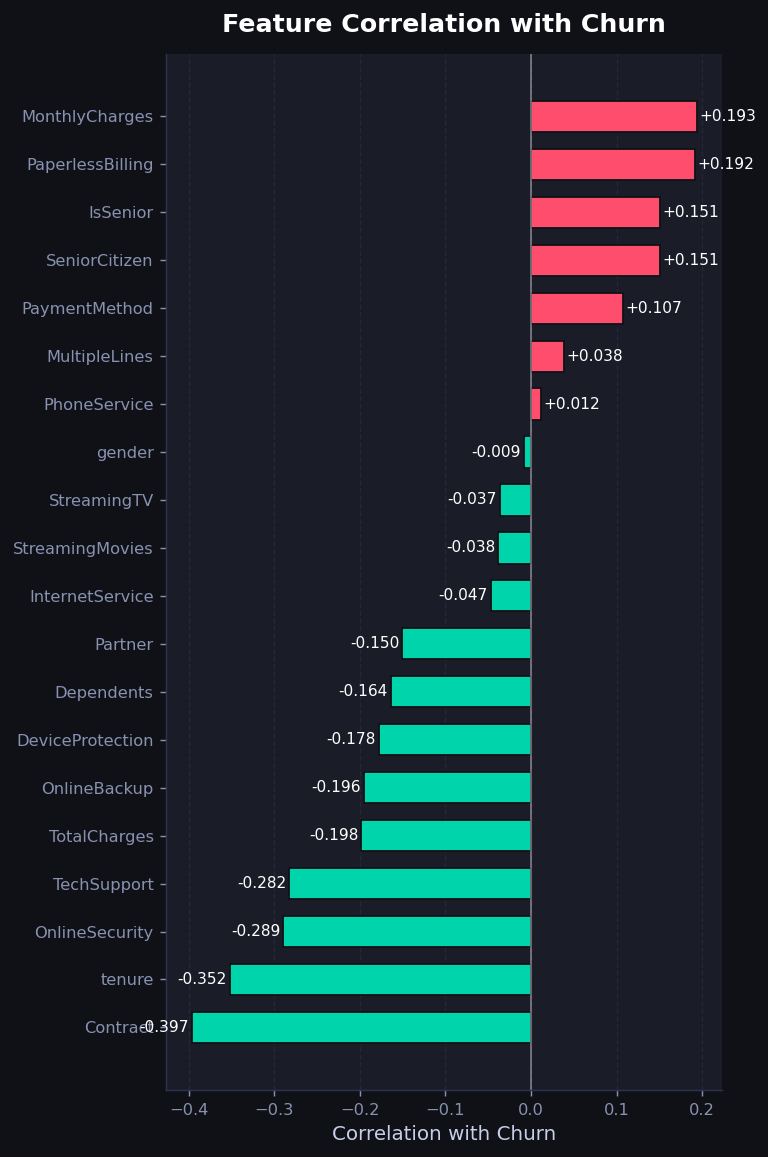

In [25]:
fig, ax = plt.subplots(figsize=(6, 9))

bar_colors = [CHURN_RED if v > 0 else RETAIN_TEAL for v in corr['Churn_Flag']]
bars = ax.barh(corr.index, corr['Churn_Flag'], color=bar_colors,
               edgecolor='#0f1117', linewidth=1, height=0.65)
ax.axvline(0, color='white', linewidth=1, alpha=0.4)
for bar, val in zip(bars, corr['Churn_Flag']):
    xpos = bar.get_width() + (0.003 if val > 0 else -0.003)
    ha   = 'left' if val > 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=8.5, ha=ha, color='white')

ax.set_xlabel('Correlation with Churn', fontsize=11)
ax.set_title('Feature Correlation with Churn', fontsize=14, fontweight='bold', pad=12)
ax.xaxis.grid(True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## High-Risk Customer Segment Profiling

In [26]:

high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['tenure'] < 12) &
    (df['InternetService'] == 'Fiber optic')
]

low_risk = df[
    (df['Contract'].isin(['One year', 'Two year'])) &
    (df['tenure'] >= 24)
]

print("high risk:")
print(f'  Customers         : {len(high_risk):,}')
print(f'  Churn Rate        : {high_risk["Churn_Flag"].mean()*100:.1f}%')
print(f'  Avg Monthly Charge: ${high_risk["MonthlyCharges"].mean():.2f}')
print(f'  Monthly Rev at Risk: ${high_risk[high_risk["Churn_Flag"]==1]["MonthlyCharges"].sum():,.2f}')
print()
print('low risk:')
print(f'  Customers         : {len(low_risk):,}')
print(f'  Churn Rate        : {low_risk["Churn_Flag"].mean()*100:.1f}%')
print(f'  Avg Monthly Charge: ${low_risk["MonthlyCharges"].mean():.2f}')
print(f'  Avg Tenure        : {low_risk["tenure"].mean():.1f} months')

high risk:
  Customers         : 876
  Churn Rate        : 70.5%
  Avg Monthly Charge: $81.77
  Monthly Rev at Risk: $50,899.50

low risk:
  Customers         : 2,725
  Churn Rate        : 6.8%
  Avg Monthly Charge: $66.78
  Avg Tenure        : 55.8 months


## Export Analysis Summary to CSV

In [27]:
df['HighRisk'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['tenure'] < 12)
).astype(int)

df['RiskScore'] = (
    (df['Contract'] == 'Month-to-month').astype(int) * 3 +
    (df['tenure'] < 12).astype(int) * 2 +
    (df['InternetService'] == 'Fiber optic').astype(int) * 2 +
    (df['OnlineSecurity'] == 'No').astype(int) * 1 +
    (df['TechSupport'] == 'No').astype(int) * 1 +
    (df['PaymentMethod'] == 'Electronic check').astype(int) * 1 +
    (df['SeniorCitizen'] == 1).astype(int) * 1
)

summary = pd.DataFrame({
    'Metric'       : ['Total Customers', 'Churned', 'Churn Rate %', 'Monthly Revenue',
                      'Revenue at Risk', 'Avg CLV (Retained)', 'Avg Tenure Churned (mo)',
                      'Avg Tenure Retained (mo)', 'Monthly Churn Rate %'],
    'Value'        : [total, churned, round(churn_rate*100,2), round(monthly_rev,2),
                      round(lost_rev,2), round(clv_retained,2),
                      round(df[df['Churn_Flag']==1]['tenure'].mean(),1),
                      round(df[df['Churn_Flag']==0]['tenure'].mean(),1),
                      round(monthly_churn_rate*100,2)]
})

summary.to_csv('churn_summary_metrics.csv', index=False)
df.to_csv('telco_churn_enriched.csv', index=False)

print(' Exported:')
print('   → churn_summary_metrics.csv  (KPI summary)')
print('   → telco_churn_enriched.csv   (full dataset with risk scores)')
print()
print('Risk Score Distribution (0=Low Risk → 11=Highest Risk):')
print(df.groupby('RiskScore').agg(
    customers=('Churn_Flag','count'),
    churn_rate=('Churn_Flag', lambda x: f"{x.mean()*100:.1f}%")
).to_string())

 Exported:
   → churn_summary_metrics.csv  (KPI summary)
   → telco_churn_enriched.csv   (full dataset with risk scores)

Risk Score Distribution (0=Low Risk → 11=Highest Risk):
           customers churn_rate
RiskScore                      
0               1294       1.8%
1                507       4.5%
2                496       8.9%
3                582       9.3%
4                500      15.4%
5                739      20.7%
6                481      27.9%
7                727      41.3%
8                672      49.9%
9                464      64.0%
10               425      73.2%
11               156      75.6%


**Key Findings**
1. Overall Churn Rate: 26.5%
The industry benchmark for telecom churn sits around 15–25%. This company is above average. 1,869 out of 7,043 customers churned in the observed period. Approximately $139,000/month in recurring revenue is at risk — nearly 30.7% of total MRR.

2. Contract Type is the Strongest Churn Predictor
Month-to-month customers churn at 42.7% — more than 15× the rate of two-year contract holders (2.8%). Over half the customer base (55%) is on month-to-month plans, making this the single largest churn risk. One-year contracts sit in the middle at 11.3%, showing that even partial commitment significantly reduces churn.

3. Fiber Optic Customers Are Disproportionately At Risk
Fiber optic churn: 41.9% vs DSL: 19.0% vs No internet: 7.4%. Fiber customers also pay the highest monthly charges, meaning they represent the highest revenue-at-risk segment. This gap likely reflects a value perception problem — customers paying premium prices but not feeling adequately supported or differentiated from competitors.

4. The First 12 Months Are the Most Critical Window
Customers in their first 6 months have the highest churn rate in the dataset. Churn steadily declines as tenure increases — customers who survive past 24 months are significantly more loyal. The average churned customer left after just 18 months, compared to 38 months for retained customers. If you can get a customer past year one, they are far more likely to stay.

5. Protective Add-on Services Reduce Churn by 15–20 Percentage Points
Customers without Online Security churn at 41.8%; those with it churn at only 14.6%. Customers without Tech Support churn at 41.7%; those with it churn at 15.2%. Device Protection and Online Backup show similar protective patterns. These services create stickiness — they increase switching costs and deepen product engagement.

6. Payment Method Is a Proxy for Engagement
Electronic check payers churn at 45.3% — nearly 3× the rate of automatic payment customers (15–16%). Automatic payment (bank transfer or credit card) correlates strongly with lower churn across all segments. Manual payment methods signal lower commitment and weaker engagement with the platform.

7. Senior Citizens and Solo Customers Are Higher-Risk Demographics
Senior citizens churn at 41.7% vs 23.6% for non-seniors. Customers with no partner and no dependents churn significantly more than those with families. These groups may need more proactive support, simpler plans, or dedicated retention outreach.

8. Higher Monthly Charges Correlate with Higher Churn
Customers paying $90+/month churn at 39.7%; those paying under $30 churn at just 11.0%. This is partly explained by Fiber optic uptake, but the trend holds even within service tiers. High-paying customers expect more — and when those expectations go unmet, they leave.

**Actionable Recommendations**
Priority 1 — Convert Month-to-Month Customers to Long-Term Contracts
Why: Contract type is the #1 predictor of churn. Locking in commitments dramatically reduces risk.
How: Offer a 1–2 month discount or free add-on for switching to an annual plan. Target month-to-month customers at the 3-month mark — before early churn risk peaks. Frame the offer around savings (e.g., "Save 15% annually vs monthly billing").
Expected impact: Reducing M2M churn from 42.7% to ~15% across just 20% of M2M customers would save approximately $18,000–$22,000/month in recovered MRR.

Priority 2 — Fix the Fiber Optic Experience
Why: Fiber customers are your most valuable (highest ARPU) and most likely to leave.
How: Conduct exit surveys with churned Fiber customers to identify root cause (pricing? reliability? support?). Bundle Online Security and Tech Support into Fiber plans at onboarding — free for the first 3 months. Introduce a Fiber loyalty tier for 12+ month customers with price-lock guarantees.
Expected impact: Even a 10pp reduction in Fiber churn (41.9% → ~32%) would retain ~315 high-value customers per cycle.

Priority 3 — Build a Stronger Onboarding Program (First 90 Days)
Why: Churn is highest in the first year. Customers who don't find value early, leave early.
How: Implement automated 30/60/90-day check-in touchpoints. At day 30, proactively recommend Online Security and Tech Support based on their plan. Flag any new customer with no add-ons and no support tickets at day 60 as at-risk — trigger a retention call or offer.
Expected impact: Reducing new-customer churn by 5pp in the first year reduces overall churn rate by ~1.5pp, saving ~$7,000/month.

Priority 4 — Migrate Electronic Check Payers to Auto-Pay
Why: Electronic check payers churn at 45.3% — the highest of any payment method.
How: Offer a small monthly credit ($3–5) for switching to automatic bank transfer or credit card. Simplify the auto-pay enrollment flow to a single click. Position it as a convenience benefit, not just a billing change.
Expected impact: Auto-pay customers churn at ~15% vs 45% — migrating even 30% of electronic check payers represents significant churn reduction.

Priority 5 — Launch a Senior Citizen Retention Program
Why: Seniors churn at 41.7% — nearly double the non-senior rate — and are often underserved.
How: Create a "Senior Simplicity" plan with bundled tech support, simplified billing, and dedicated phone support. Assign proactive support to seniors in their first 12 months. Offer a loyalty discount at the 12-month anniversary.

Summary Metrics at a Glance
MetricValueTotal Customers7,043Churned Customers1,869 (26.5%)Monthly Revenue~$456,000(30.7%)Avg CLV — Retained Customer~$2,300Avg Tenure — Churned18 monthsAvg Tenure — Retained38 monthsHighest Churn SegmentM2M + Fiber + No Security (>55%)Lowest Churn SegmentTwo-year contract + Tenure >24mo (<5%)

**Recommended Next Steps**

Build a churn prediction model using Logistic Regression or XGBoost on the risk features engineered in this notebook — enabling proactive, real-time intervention before customers decide to leave.
A/B test the contract conversion offer on a subset of month-to-month customers before rolling out company-wide.
Set up a retention dashboard tracking monthly churn rate, MRR at risk, and at-risk segment sizes as live KPIs for the product and growth teams.
Run exit interviews with 10–15 churned Fiber optic customers to validate whether the issue is pricing, reliability, or lack of perceived value.